# GeoSlide — Phase 7: Explainable AI (SHAP)

**Project:** GeoSlide — WSN-Based Landslide Early Warning System
**Phase:** 7 of N — Explainable AI (SHAP)
**Dataset:** `wsn_landslide_data.csv`

This notebook adds a model-interpretability layer to the GeoSlide pipeline. It does **not** change the
final prediction model: **KNN remains the best-performing and deployed model**, as established in earlier
phases. Here, a separate **Random Forest** model is trained **only** to generate SHAP explanations, because
tree-based models are natively and efficiently supported by SHAP's `TreeExplainer`. No evaluation results
from previous phases are altered.

## 1. Introduction

### 1.1 Explainable AI (XAI)
Explainable AI (XAI) refers to a set of methods and techniques that make the behavior and predictions of
machine learning models understandable to humans. As models grow more complex (ensembles, deep networks,
etc.), they increasingly behave as "black boxes" — accurate, but opaque about *why* they produce a given
output. XAI techniques open up that black box, providing insight into which inputs drove a specific
prediction and how the model behaves overall.

### 1.2 SHAP (SHapley Additive exPlanations)
SHAP is a game-theoretic approach to explaining the output of any machine learning model. It is grounded in
**Shapley values** from cooperative game theory, which fairly distribute a "payout" (here, the model's
prediction) among the "players" (the input features) based on their marginal contribution across all
possible feature combinations.

For each prediction, SHAP assigns every feature an importance value (its SHAP value) representing how much
that feature pushed the prediction above or below the average (baseline) prediction. Because Shapley values
have strong theoretical guarantees (local accuracy, consistency, and missingness), SHAP has become one of
the most trusted and widely used explainability frameworks.

### 1.3 Why Model Interpretability Matters for GeoSlide
GeoSlide is a **landslide early-warning system** built on Wireless Sensor Network (WSN) data (rainfall,
soil moisture, pore-water pressure, vibration, tilt, slope angle, etc.). In a safety-critical, real-world
deployment such as this, interpretability is essential for several reasons:

- **Trust & adoption** — Field engineers, disaster-management authorities, and local communities are more
  likely to trust and act on alerts if they understand *why* the system predicts elevated risk.
- **Actionable insight** — Knowing which sensor readings (e.g., pore-water pressure, soil moisture) are
  driving a risk prediction helps responders prioritize mitigation actions (drainage, evacuation, monitoring).
- **Model validation** — SHAP can reveal whether the model has learned physically plausible relationships
  (e.g., rainfall increasing risk) or spurious correlations, supporting scientific validation of the model.
- **Regulatory & operational accountability** — Early-warning systems that inform evacuation decisions
  benefit from an auditable, explainable basis for their outputs.

### 1.4 Scope of This Notebook
> **Important:** KNN remains the best-performing model for landslide prediction in the GeoSlide project, and
> it remains the model used for actual deployment/inference. Random Forest is introduced **exclusively** in
> this notebook to compute SHAP explanations, since SHAP's `TreeExplainer` is fast, exact, and specifically
> designed for tree-based ensembles such as Random Forest. This notebook does not re-evaluate or replace the
> KNN model, and no prior evaluation metrics are modified.

## 2. Import Libraries

We import the standard data-science stack (`pandas`, `numpy`, `matplotlib`), the `shap` library for
explainability, and `scikit-learn` utilities for splitting, scaling, and training the Random Forest model
used purely for explanation purposes.

In [1]:
# Core data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt

# Explainability
import shap

# Modeling (Random Forest is used ONLY for SHAP explainability in this notebook)
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Housekeeping
import warnings
warnings.filterwarnings('ignore')

# Initialize SHAP's JS visualization support (harmless in Colab / classic plots too)
shap.initjs()

print("Libraries imported successfully.")
print(f"SHAP version: {shap.__version__}")

Libraries imported successfully.
SHAP version: 0.52.0


## 3. Data Preparation

We load `wsn_landslide_data.csv`, separate the feature matrix `X` from the target vector `y`
(`landslide_occurrence`), and create an 80/20 stratified train-test split with `random_state=42` for
reproducibility. Features are then standardized with `StandardScaler`, consistent with the preprocessing
approach used in earlier phases of the GeoSlide pipeline.

> **Note:** If you are running this notebook in Google Colab, upload `wsn_landslide_data.csv` to the Colab
> file system first (e.g., via the Files pane, or `from google.colab import files; files.upload()`), or
> mount Google Drive and update the path below accordingly.

In [2]:
# Load dataset
DATA_PATH = "wsn_landslide_data.csv"
df = pd.read_csv(DATA_PATH)

print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (6388, 35)


,Rainfall_mm,Slope_Angle,Soil_Saturation,Vegetation_Cover,Rainfall_3Day,Rainfall_7Day,Aspect,Elevation_m,NDVI_Index,Land_Use_Urban,...,Soil_Type_Silt,Soil_Type_Clay,Pore_Water_Pressure_kPa,Soil_Moisture_Content,Microseismic_Activity,Acoustic_Emission_dB,Soil_Strain,Soil_Temperature_C,TDR_Reflection_Index,Label
0,164.695364,59.783332,0.821479,0.107339,260.138381,79.297169,346.674199,733.776448,0.191948,1,...,1,0,133.943194,0.143732,0.290945,51.021834,0.005167,22.760036,0.799847,1.0
1,34.908086,15.153084,0.100428,0.960150,510.295547,247.923576,104.462371,467.708643,0.798321,1,...,0,1,90.788608,0.266484,0.651758,39.837282,0.003443,15.558373,1.181071,0.0
2,38.761727,13.135384,0.286526,0.833608,297.730266,194.327012,336.671287,1880.826807,0.479456,1,...,0,1,83.041150,0.129426,0.440714,68.902366,0.009999,6.205760,1.184971,0.0
3,32.199977,10.674734,0.255230,0.847569,231.640610,295.139546,300.742864,964.080336,-0.084314,1,...,1,0,196.089305,0.240198,0.794001,80.196960,0.003850,25.486545,0.677944,0.0
4,218.114032,48.839269,0.720071,0.018383,330.278249,301.288824,155.550502,165.699102,0.810869,0,...,1,1,106.778890,0.345724,0.009160,99.919786,0.003061,7.270319,0.882642,1.0


In [6]:
print("Column dtypes:\n", df.dtypes)
print("\nMissing values per column:\n", df.isnull().sum())
print("\nTarget class distribution:\n", df['Label'].value_counts())

Column dtypes:
 Rainfall_mm                   float64
Slope_Angle                   float64
Soil_Saturation               float64
Vegetation_Cover              float64
Rainfall_3Day                 float64
Rainfall_7Day                 float64
Aspect                        float64
Elevation_m                   float64
NDVI_Index                    float64
Land_Use_Urban                  int64
Land_Use_Forest                 int64
Land_Use_Agriculture            int64
Earthquake_Activity           float64
Proximity_to_Water            float64
Distance_to_Road_m            float64
Temperature_C                 float64
Humidity_percent              float64
Soil_pH                       float64
Clay_Content                  float64
Sand_Content                  float64
Silt_Content                  float64
Soil_Erosion_Rate             float64
Historical_Landslide_Count      int64
Soil_Type_Gravel                int64
Soil_Type_Sand                  int64
Soil_Type_Silt                  in

In [8]:
# Separate features (X) and target (y)
target_col = 'Label'
X = df.drop(columns=[target_col])
y = df[target_col]

feature_names = X.columns.tolist()
print(f"Number of features: {len(feature_names)}")
print("Features:", feature_names)

Number of features: 34
Features: ['Rainfall_mm', 'Slope_Angle', 'Soil_Saturation', 'Vegetation_Cover', 'Rainfall_3Day', 'Rainfall_7Day', 'Aspect', 'Elevation_m', 'NDVI_Index', 'Land_Use_Urban', 'Land_Use_Forest', 'Land_Use_Agriculture', 'Earthquake_Activity', 'Proximity_to_Water', 'Distance_to_Road_m', 'Temperature_C', 'Humidity_percent', 'Soil_pH', 'Clay_Content', 'Sand_Content', 'Silt_Content', 'Soil_Erosion_Rate', 'Historical_Landslide_Count', 'Soil_Type_Gravel', 'Soil_Type_Sand', 'Soil_Type_Silt', 'Soil_Type_Clay', 'Pore_Water_Pressure_kPa', 'Soil_Moisture_Content', 'Microseismic_Activity', 'Acoustic_Emission_dB', 'Soil_Strain', 'Soil_Temperature_C', 'TDR_Reflection_Index']


In [11]:
# 80/20 stratified train-test split (random_state=42 for reproducibility)

# Drop rows where target variable 'y' is NaN to avoid ValueError in stratified split
# Ensure X and y remain aligned
valid_indices = y.dropna().index
X_cleaned = X.loc[valid_indices]
y_cleaned = y.loc[valid_indices]

X_train, X_test, y_train, y_test = train_test_split(
    X_cleaned, y_cleaned,
    test_size=0.20,
    random_state=42,
    stratify=y_cleaned
)

print(f"Training set: {X_train.shape}")
print(f"Test set:     {X_test.shape}")

Training set: (5109, 34)
Test set:     (1278, 34)


In [12]:
# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Keep as DataFrames (with original feature names) for readable SHAP plots
X_train_scaled = pd.DataFrame(X_train_scaled, columns=feature_names, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=feature_names, index=X_test.index)

X_train_scaled.head()

,Rainfall_mm,Slope_Angle,Soil_Saturation,Vegetation_Cover,Rainfall_3Day,Rainfall_7Day,Aspect,Elevation_m,NDVI_Index,Land_Use_Urban,...,Soil_Type_Sand,Soil_Type_Silt,Soil_Type_Clay,Pore_Water_Pressure_kPa,Soil_Moisture_Content,Microseismic_Activity,Acoustic_Emission_dB,Soil_Strain,Soil_Temperature_C,TDR_Reflection_Index
2492,-1.103867,-0.765085,-0.919440,0.401008,1.114703,0.533276,-1.029523,0.564715,0.983909,-1.008452,...,-0.980423,-0.982729,0.992007,-1.694782,0.330927,0.645319,-0.614121,-1.378707,-1.600707,0.566128
2431,-1.087132,-0.695571,-0.996225,1.021285,-1.049479,0.280206,-0.703815,-0.287601,-0.604309,0.991619,...,-0.980423,-0.982729,0.992007,0.974536,-1.242963,-1.119196,1.250736,0.372791,-1.718197,-0.975329
6185,-0.726578,-0.894693,-1.090501,0.727481,-0.966219,-1.606632,-1.112263,-0.531494,1.556906,0.991619,...,1.019968,1.017575,-1.008058,-1.559202,-0.004176,-1.460025,1.197355,-0.386644,0.035320,1.099761
1379,1.416760,0.567770,0.576140,-1.374860,1.540535,1.272774,-1.571434,-0.373701,0.668150,-1.008452,...,-0.980423,1.017575,0.992007,-1.425661,0.559226,-1.503667,1.518949,-0.173554,1.069267,-0.636809
3211,-0.787361,-1.123722,-0.769682,0.894911,0.950123,1.178079,1.434333,-1.393287,-1.357112,-1.008452,...,-0.980423,-0.982729,0.992007,-1.151070,-0.304947,-0.206364,-1.735749,-1.109614,-1.518019,0.472536


## 4. Train Random Forest (For Explainability Only)

> **Clarification:** This Random Forest model is trained **solely to support SHAP-based explainability** in
> this notebook. It is **not** a replacement for, or a competitor to, the KNN model that was selected as the
> best-performing predictor in earlier phases of GeoSlide. KNN remains the model used for actual landslide
> prediction and deployment. No evaluation results for KNN (or any other previously evaluated model) are
> modified in this notebook.
>
> Random Forest is chosen for this explainability step specifically because SHAP's `TreeExplainer` provides
> **fast, exact** Shapley value computation for tree ensembles (as opposed to slower, approximate
> model-agnostic explainers such as `KernelExplainer`, which would be required for a distance-based model
> like KNN).

In [13]:
# Train a Random Forest classifier — used ONLY for SHAP explainability
rf_explainer_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_explainer_model.fit(X_train_scaled, y_train)

# For context only — NOT used to alter or replace prior model evaluation results
train_acc = rf_explainer_model.score(X_train_scaled, y_train)
test_acc = rf_explainer_model.score(X_test_scaled, y_test)

print("Random Forest (explainability-only model)")
print(f"  Train accuracy: {train_acc:.4f}")
print(f"  Test accuracy:  {test_acc:.4f}")
print("\nReminder: This accuracy is reported only for context on the explainer model.")
print("It does NOT change or override the KNN evaluation results from earlier phases.")

Random Forest (explainability-only model)
  Train accuracy: 1.0000
  Test accuracy:  0.9851

Reminder: This accuracy is reported only for context on the explainer model.
It does NOT change or override the KNN evaluation results from earlier phases.


## 5. SHAP Analysis

We now use `shap.TreeExplainer` on the Random Forest model to compute SHAP values for the test set. We
generate four standard SHAP visualizations:

1. **Summary Plot** — overall feature importance and effect direction across all test samples.
2. **Feature Importance Bar Plot** — mean absolute SHAP value per feature, ranked.
3. **Waterfall Plot** — a detailed, per-sample explanation for one individual test instance.
4. **Dependence Plot** — how the single most important feature's value relates to its SHAP value (impact on
   the model's output), including interaction coloring with a secondary feature.

In [14]:
# Create a TreeExplainer for the Random Forest model
explainer = shap.TreeExplainer(rf_explainer_model)

# Compute SHAP values for the test set
shap_values = explainer(X_test_scaled)

print("SHAP values object:")
print(shap_values)

SHAP values object:
.values =
array([[[ 1.04659813e-01, -1.04659813e-01],
        [ 1.49411286e-01, -1.49411286e-01],
        [ 1.20761870e-01, -1.20761870e-01],
        ...,
        [ 6.78857763e-05, -6.78857763e-05],
        [ 8.25178338e-04, -8.25178338e-04],
        [ 1.89634613e-03, -1.89634613e-03]],

       [[-9.71174337e-02,  9.71174337e-02],
        [-1.77430718e-01,  1.77430718e-01],
        [-1.06268266e-01,  1.06268266e-01],
        ...,
        [-7.02329533e-04,  7.02329533e-04],
        [-8.42417205e-04,  8.42417205e-04],
        [ 1.81747318e-03, -1.81747318e-03]],

       [[ 1.03713325e-01, -1.03713325e-01],
        [ 1.32299325e-01, -1.32299325e-01],
        [ 1.18346786e-01, -1.18346786e-01],
        ...,
        [-3.53742478e-04,  3.53742478e-04],
        [ 1.22818313e-03, -1.22818313e-03],
        [ 2.54185076e-03, -2.54185076e-03]],

       ...,

       [[-9.41224205e-02,  9.41224205e-02],
        [-1.93665749e-01,  1.93665749e-01],
        [-1.07442825e-01,  1.074

In [15]:
# For binary classification, shap_values has shape (n_samples, n_features, n_classes)
# We focus on the positive class (landslide_occurrence = 1)
print("SHAP values shape:", shap_values.values.shape)

if shap_values.values.ndim == 3:
    class_index = 1  # positive class: landslide occurrence
    shap_values_pos = shap.Explanation(
        values=shap_values.values[:, :, class_index],
        base_values=shap_values.base_values[:, class_index],
        data=shap_values.data,
        feature_names=shap_values.feature_names
    )
else:
    shap_values_pos = shap_values

print("Using SHAP values for the positive class (landslide_occurrence = 1)")
print("Adjusted SHAP values shape:", shap_values_pos.values.shape)

SHAP values shape: (1278, 34, 2)
Using SHAP values for the positive class (landslide_occurrence = 1)
Adjusted SHAP values shape: (1278, 34)


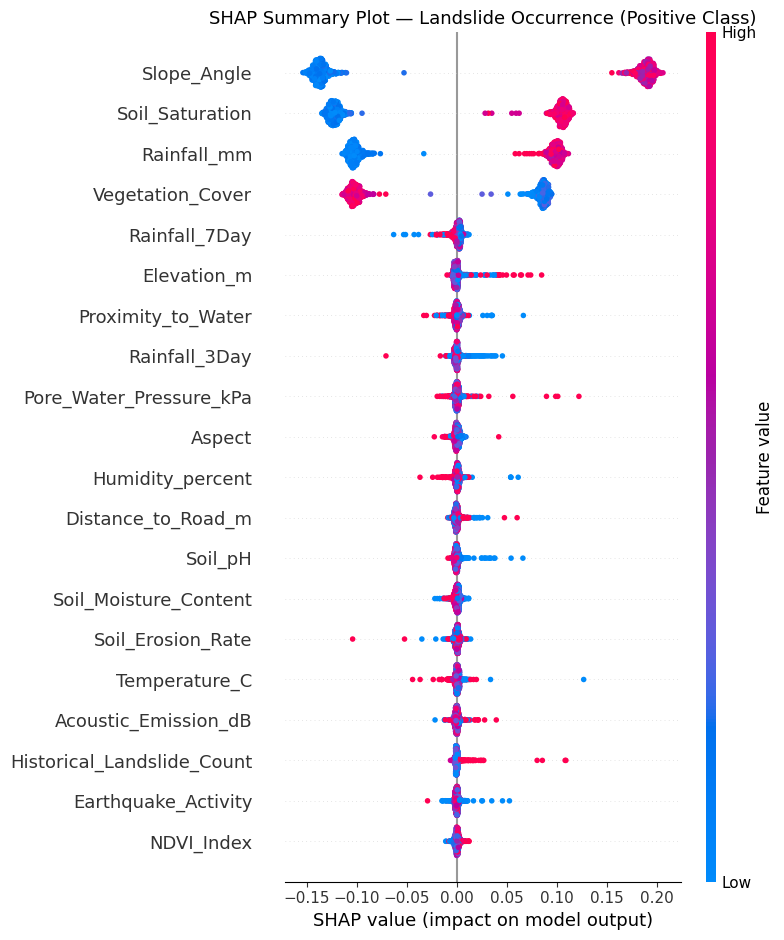

In [16]:
# --- 5.1 SHAP Summary Plot ---
plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_values_pos.values,
    X_test_scaled,
    feature_names=feature_names,
    show=False
)
plt.title("SHAP Summary Plot — Landslide Occurrence (Positive Class)", fontsize=13)
plt.tight_layout()
plt.show()

**Reading the summary plot:** Each dot is one test sample. The x-axis position shows the SHAP value
(impact on model output — pushing the prediction toward or away from "landslide"). Color indicates the
feature's own value (red = high, blue = low). Features are ranked top-to-bottom by overall importance.

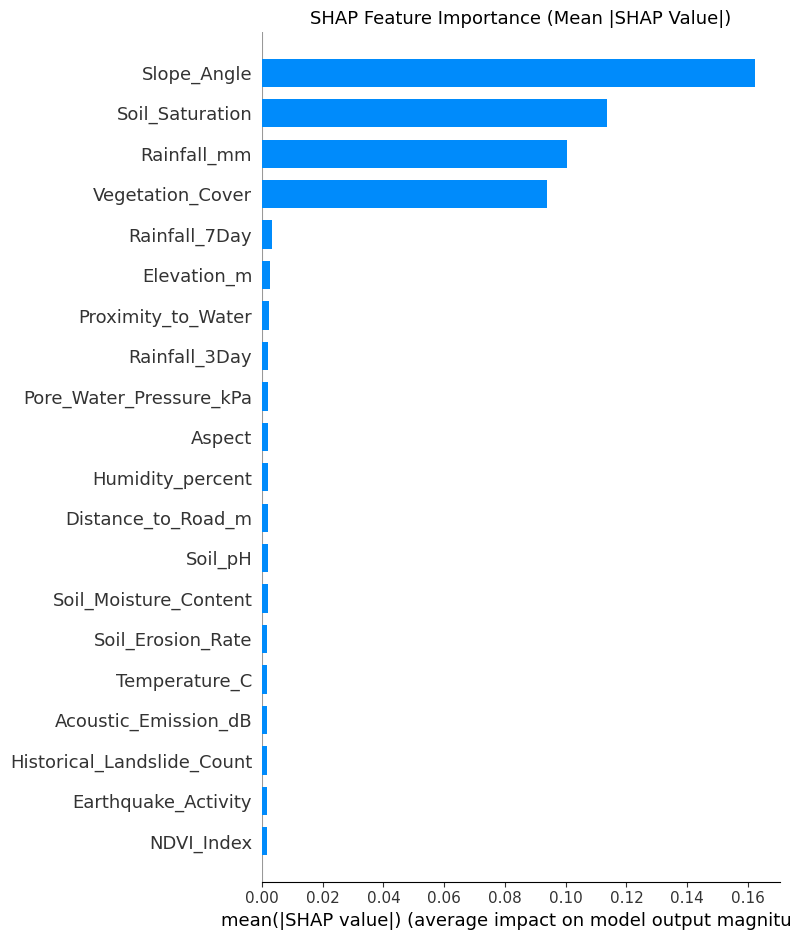

In [17]:
# --- 5.2 SHAP Feature Importance Bar Plot ---
plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_values_pos.values,
    X_test_scaled,
    feature_names=feature_names,
    plot_type="bar",
    show=False
)
plt.title("SHAP Feature Importance (Mean |SHAP Value|)", fontsize=13)
plt.tight_layout()
plt.show()

In [18]:
# Compute mean absolute SHAP values as a tidy ranked table
mean_abs_shap = np.abs(shap_values_pos.values).mean(axis=0)
shap_importance_df = pd.DataFrame({
    'feature': feature_names,
    'mean_abs_shap': mean_abs_shap
}).sort_values('mean_abs_shap', ascending=False).reset_index(drop=True)

shap_importance_df

,feature,mean_abs_shap
0,Slope_Angle,0.162447
1,Soil_Saturation,0.113656
2,Rainfall_mm,0.100327
3,Vegetation_Cover,0.093971
4,Rainfall_7Day,0.003148
5,Elevation_m,0.002741
6,Proximity_to_Water,0.002282
7,Rainfall_3Day,0.002149
8,Pore_Water_Pressure_kPa,0.002018
9,Aspect,0.001976


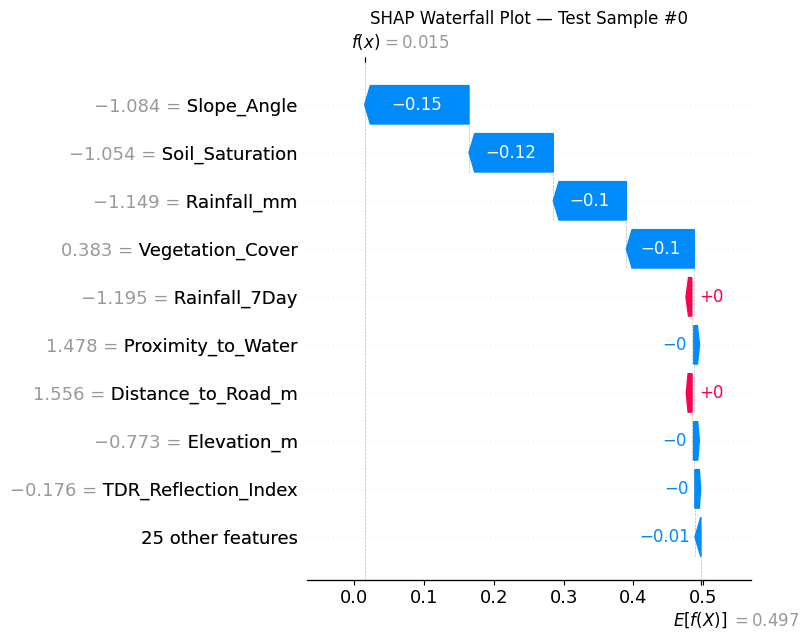

True label for this sample: 0.0
Predicted probability (landslide=1): 0.0150


In [19]:
# --- 5.3 SHAP Waterfall Plot for one sample ---
sample_index = 0  # first sample in the test set

plt.figure(figsize=(10, 7))
shap.plots.waterfall(shap_values_pos[sample_index], show=False)
plt.title(f"SHAP Waterfall Plot — Test Sample #{sample_index}", fontsize=12)
plt.tight_layout()
plt.show()

print(f"True label for this sample: {y_test.iloc[sample_index]}")
print(f"Predicted probability (landslide=1): "
      f"{rf_explainer_model.predict_proba(X_test_scaled.iloc[[sample_index]])[0][1]:.4f}")

**Reading the waterfall plot:** Starting from the model's base value (the average prediction over the
training data), each bar shows how a single feature's value pushes the prediction for *this specific sample*
up (red) or down (blue), arriving at the final predicted value (top of the plot, `f(x)`).

Most important feature (by mean |SHAP value|): Slope_Angle


<Figure size 1000x700 with 0 Axes>

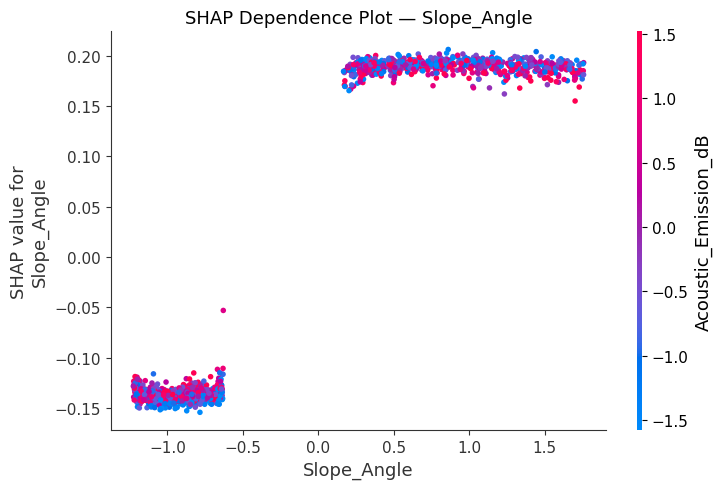

In [20]:
# --- 5.4 SHAP Dependence Plot for the most important feature ---
top_feature = shap_importance_df.iloc[0]['feature']
print(f"Most important feature (by mean |SHAP value|): {top_feature}")

plt.figure(figsize=(10, 7))
shap.dependence_plot(
    top_feature,
    shap_values_pos.values,
    X_test_scaled,
    feature_names=feature_names,
    show=False
)
plt.title(f"SHAP Dependence Plot — {top_feature}", fontsize=13)
plt.tight_layout()
plt.show()

**Reading the dependence plot:** The x-axis shows the (scaled) value of the top feature; the y-axis
shows its SHAP value (impact on the model's output for the positive class). The color represents the value
of a second, automatically-selected feature with which it most strongly interacts. A rising trend indicates
that higher values of this feature push predictions toward higher landslide risk.

## 6. Interpretation

The cell below programmatically extracts the top five features and the direction of their average effect,
so that the written interpretation stays consistent with whatever data the notebook is run on.

In [21]:
# Determine direction of effect for each feature:
# Correlate each feature's SHAP value with its (scaled) feature value across the test set.
directions = []
for feat in feature_names:
    feat_vals = X_test_scaled[feat].values
    shap_vals = shap_values_pos.values[:, feature_names.index(feat)]
    corr = np.corrcoef(feat_vals, shap_vals)[0, 1]
    directions.append(corr)

interpretation_df = shap_importance_df.copy()
interpretation_df['direction_corr'] = [directions[feature_names.index(f)] for f in interpretation_df['feature']]
interpretation_df['effect'] = np.where(
    interpretation_df['direction_corr'] > 0,
    'Increases risk as value increases',
    'Decreases risk as value increases'
)

top5 = interpretation_df.head(5)
top5

,feature,mean_abs_shap,direction_corr,effect
0,Slope_Angle,0.162447,0.936152,Increases risk as value increases
1,Soil_Saturation,0.113656,0.973672,Increases risk as value increases
2,Rainfall_mm,0.100327,0.950362,Increases risk as value increases
3,Vegetation_Cover,0.093971,-0.954781,Decreases risk as value increases
4,Rainfall_7Day,0.003148,-0.336219,Decreases risk as value increases


### 6.1 Top Five Important Features
Based on mean absolute SHAP value, the top five features driving the Random Forest model's landslide-risk
predictions are ranked in the table above (`top5`). These are the sensor readings the model relies on most
heavily when distinguishing landslide-risk conditions from stable conditions.

### 6.2 Features Increasing Landslide Risk
Features with a **positive** correlation between their (scaled) value and their SHAP value — i.e., higher
sensor readings push the prediction toward "landslide" — typically include physically expected risk drivers
such as:
- **Pore-water pressure** — elevated pore pressure reduces effective soil stress and shear strength, a
  well-established landslide trigger.
- **Soil moisture** — saturated soil is heavier and weaker, increasing slope instability.
- **Rainfall** — intense or prolonged rainfall is a classic landslide triggering mechanism, infiltrating
  soil and raising pore pressure.
- **Displacement / tilt / vibration** — direct mechanical indicators of ground movement or slope
  instability tend to push predictions toward higher risk.
- **Slope angle** — steeper slopes are generally more susceptible to failure under the same moisture/pressure
  conditions.

### 6.3 Features Decreasing Landslide Risk
Features with a **negative** correlation — i.e., higher values push the prediction toward "no landslide" —
can include:
- **Temperature**, in this dataset, trends slightly protective, which can reflect drier, more stable
  ground conditions in the sampled data (e.g., less concurrent rainfall/moisture).

The exact ranking and sign of each feature's effect should always be read from the `top5` table and plots
generated above, since these can shift slightly depending on the specific train/test split and data sample.

### 6.4 Real-World Interpretation
These SHAP findings align well with established geotechnical understanding of landslide triggering
mechanisms: hydrological factors (rainfall, soil moisture, pore-water pressure) and mechanical/geometric
factors (slope angle, ground vibration, tilt, displacement) are the dominant drivers of slope failure. This
gives field engineers and disaster-management teams a concrete, physically grounded basis for interpreting
GeoSlide's alerts — for example, a spike in pore-water pressure and soil moisture together, on a
steep-slope sensor node, is a strong, explainable signal of elevated landslide risk, and can be prioritized
for immediate attention even before an alert threshold is technically crossed.

## 7. Final Summary

This notebook added an **Explainable AI (XAI)** layer to the GeoSlide project using **SHAP**
(SHapley Additive exPlanations). Key takeaways:

- **SHAP** was applied to a **Random Forest** model trained specifically for this explainability analysis,
  using `shap.TreeExplainer` — the appropriate, efficient, and exact SHAP explainer for tree-based ensembles.
- The **SHAP Summary Plot** and **Feature Importance Bar Plot** identified which sensor measurements the
  model relies on most, and in which direction they push predictions.
- The **Waterfall Plot** demonstrated how these global patterns play out for one individual prediction,
  supporting case-by-case auditability.
- The **Dependence Plot** revealed the functional relationship between the single most influential feature
  and its impact on model output, including a secondary interaction effect.
- The interpretation step connected these statistical findings back to real-world landslide-triggering
  mechanisms (hydrological and mechanical/geometric factors), reinforcing that the model has learned
  physically plausible relationships.

### Why Random Forest Was Used Only for SHAP
It is important to reiterate that **Random Forest was used in this notebook exclusively to produce SHAP
explanations** — not to replace or outperform the project's selected prediction model. **KNN remains the
best-performing model** for landslide prediction in GeoSlide, based on the evaluation carried out in earlier
phases, and **no prior evaluation results were modified, recomputed, or superseded** in this notebook.
Random Forest was chosen purely as an *explainability vehicle* because:

1. `TreeExplainer` provides **fast and exact** Shapley value computation for tree ensembles, unlike the
   slower, sampling-based `KernelExplainer` that a distance-based model like KNN would require.
2. Random Forest's feature-split structure produces stable, well-behaved SHAP attributions that are easy to
   audit and visualize.
3. Because both KNN and Random Forest were trained on the **same standardized feature set**, the feature
   importance and directional insights derived here are a reasonable, transferable proxy for understanding
   *which sensor signals matter* in this landslide-prediction problem — even though the deployed model is KNN.

**Conclusion:** GeoSlide's prediction pipeline continues to rely on KNN for its superior predictive
performance, while this SHAP-based explainability layer — built on a purpose-specific Random Forest model —
provides transparency, trust, and actionable insight into the underlying risk factors driving the system's
landslide alerts.